## Iris Dataset with SOM

### Use case: Visualizing 4D Iris data in 2D

Step-by-step explanation:
1. Normalize input
2. Train SOM
3. Visualize clusters by species

*Output: U-Matrix, component planes*

In [1]:
# Install Required Libraries
# Uncomment if not installed
# !pip install minisom

In [2]:
# Load and Preprocess the Dataset
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

In [3]:
# Load Iris dataset
iris = load_iris()
data = iris.data
labels = iris.target
label_names = iris.target_names

In [4]:
# Normalize data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [5]:
# Initialize and Train SOM
som_shape = (10, 10)
som = MiniSom(x=som_shape[0], y=som_shape[1], input_len=data.shape[1],
              sigma=1.0, learning_rate=0.5, random_seed=42)
som.train(data, num_iteration=100)
print("SOM training complete.")

SOM training complete.


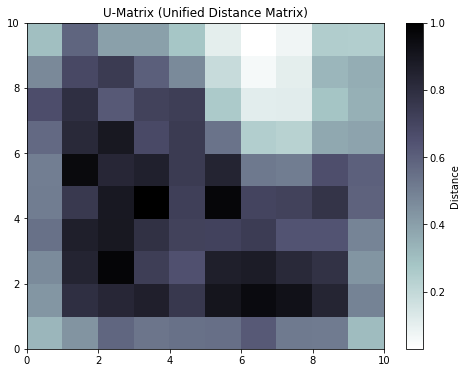

In [6]:
# Task 4: Visualize the U-Matrix
plt.figure(figsize=(8, 6))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance')
plt.title('U-Matrix (Unified Distance Matrix)')
plt.show()

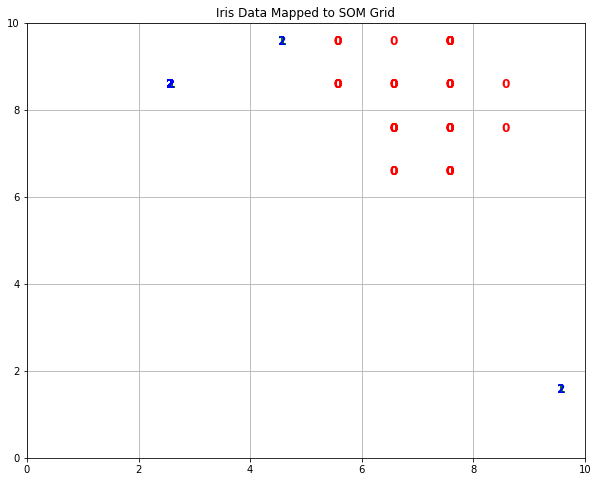

In [7]:
# Overlay Labels on the SOM
label_colors = ['r', 'g', 'b']  # Red, Green, Blue for 3 Iris classes

plt.figure(figsize=(10, 8))
for i, x in enumerate(data):
    w = som.winner(x)  # position of the BMU
    plt.text(w[0] + 0.5, w[1] + 0.5, str(labels[i]),
             color=label_colors[labels[i]], fontdict={'weight': 'bold', 'size': 12})

plt.xlim([0, som_shape[0]])
plt.ylim([0, som_shape[1]])
plt.title('Iris Data Mapped to SOM Grid')
plt.grid(True)
plt.show()